# Mini Project 5-4 Explore confidence intervals

## Introduction

The Air Quality Index (AQI) is the Environmental Protection Agency's index for reporting air quality. A value close to 0 signals little to no public health concern, while higher values are associated with increased risk to public health. The United States is considering a new federal policy that would create a subsidy for renewable energy in states observing an average AQI of 10 or above. <br>

You've just started your new role as a data analyst in the Strategy division of Ripple Renewable Energy (RRE). **RRE operates in the following U.S. states: `California`, `Florida`, `Michigan`, `Ohio`, `Pennsylvania`, `Texas`.** You've been tasked with constructing an analysis which identifies which of these states are most likely to be affected, should the new federal policy be enacted.

Your manager has requested that you do the following for your analysis:
1. Provide a summary of the mean AQI for the states in which RRE operates.
2. Construct a boxplot visualization for AQI of these states using `seaborn`.
3. Evaluate which state(s) may be most affected by this policy, based on the data and your boxplot visualization.
4. Construct a confidence interval for the RRE state with the highest mean AQI.

## Step 1: Imports

### Import packages

Import `pandas` and `numpy`.

In [1]:
# Import relevant packages
import numpy as np
import pandas as pd

### Load the dataset

The dataset provided gives national Air Quality Index (AQI) measurements by state over time.  `Pandas` is used to import the file `c4_epa_air_quality.csv` as a DataFrame named `aqi`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

*Note: For the purposes of your analysis, you can assume this data is randomly sampled from a larger population.*

In [7]:
# Import data
aqi = pd.read_csv('/Users/viviansabga/Desktop/Desktop - Vivian’s MacBook Pro - 1/NORTHEASTERN/Econ/c4_epa_air_quality.csv')
aqi.head(10)

,Unnamed: 0,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
0,0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,0.473684,7
1,1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,0.263158,5
2,2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,0.111111,2
3,3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,0.300000,3
4,4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,0.215789,3
5,5,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,0.994737,14
6,6,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,0.200000,2
7,7,2018-01-01,Pennsylvania,Erie,Erie,NaN,Carbon monoxide,Parts per million,0.200000,2
8,8,2018-01-01,Hawaii,Honolulu,Honolulu,Honolulu,Carbon monoxide,Parts per million,0.400000,5
9,9,2018-01-01,Colorado,Larimer,Fort Collins,Fort Collins - CSU - S. Mason,Carbon monoxide,Parts per million,0.300000,6


## Step 2: Data exploration

### Explore your dataset

Before proceeding to your deliverables, spend some time exploring the `aqi` DataFrame. 

In [3]:
# Code Here
# Get dataset info (columns, data types, missing values)
aqi.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        260 non-null    int64  
 1   date_local        260 non-null    object 
 2   state_name        260 non-null    object 
 3   county_name       260 non-null    object 
 4   city_name         260 non-null    object 
 5   local_site_name   257 non-null    object 
 6   parameter_name    260 non-null    object 
 7   units_of_measure  260 non-null    object 
 8   arithmetic_mean   260 non-null    float64
 9   aqi               260 non-null    int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 20.4+ KB


In [4]:
# Code Here
# Summary statistics for numerical columns
aqi.describe()


,Unnamed: 0,arithmetic_mean,aqi
count,260.000000,260.000000,260.000000
mean,129.500000,0.403169,6.757692
std,75.199734,0.317902,7.061707
min,0.000000,0.000000,0.000000
25%,64.750000,0.200000,2.000000
50%,129.500000,0.276315,5.000000
75%,194.250000,0.516009,9.000000
max,259.000000,1.921053,50.000000


In [5]:
# Code Here
# Count missing values per column
aqi.isnull().sum()


Unnamed: 0          0
date_local          0
state_name          0
county_name         0
city_name           0
local_site_name     3
parameter_name      0
units_of_measure    0
arithmetic_mean     0
aqi                 0
dtype: int64

**Question:** What time range does this data cover?

In [9]:
# Code Here
# Convert date column (assuming it's named 'date') to datetime format
aqi['date_local'] = pd.to_datetime(aqi['date_local'])

# Find the min and max date
start_date = aqi['date_local'].min()
end_date = aqi['date_local'].max()

print(f"Time Range Covered: {start_date} to {end_date}")


Time Range Covered: 2018-01-01 00:00:00 to 2018-01-01 00:00:00


A: 2018-01-01 00:00:00 to 2018-01-01 00:00:00

**Question:** What are the minimum and maximum AQI values observed in the dataset?

In [10]:
# Code Here
# Find the minimum and maximum AQI values
min_aqi = aqi['aqi'].min()
max_aqi = aqi['aqi'].max()

print(f"Minimum AQI: {min_aqi}")
print(f"Maximum AQI: {max_aqi}")


Minimum AQI: 0
Maximum AQI: 50


**Question:** Are all states equally represented in the dataset?

In [14]:
# Code Here
# Count occurrences of each state in the dataset
state_counts = aqi['state_name'].value_counts()

print(state_counts)

state_name
California              66
Arizona                 14
Ohio                    12
Florida                 12
Texas                   10
New York                10
Pennsylvania            10
Michigan                 9
Colorado                 9
Minnesota                7
New Jersey               6
Indiana                  5
North Carolina           4
Massachusetts            4
Maryland                 4
Oklahoma                 4
Virginia                 4
Nevada                   4
Connecticut              4
Kentucky                 3
Missouri                 3
Wyoming                  3
Iowa                     3
Hawaii                   3
Utah                     3
Vermont                  3
Illinois                 3
New Hampshire            2
District Of Columbia     2
New Mexico               2
Montana                  2
Oregon                   2
Alaska                   2
Georgia                  2
Washington               2
Idaho                    2
Nebraska         

A: No

## Step 3: Statistical tests

### Summarize the mean AQI for RRE states

Start with your first deliverable. Summarize the mean AQI for the states in which RRE operates (California, Florida, Michigan, Ohio, Pennsylvania, and Texas).

In [18]:
import pandas as pd

# Define the list of RRE states
rre_states = ["California", "Florida", "Michigan", "Ohio", "Pennsylvania", "Texas"]

# Subset the AQI data to only include RRE states
aqi_rre = aqi[aqi["state_name"].isin(rre_states)]

# Calculate the mean AQI for each RRE state
mean_aqi_rre = aqi_rre.groupby("state_name")["aqi"].mean().reset_index()

print(mean_aqi_rre.to_string(index=False))

  state_name       aqi
  California 12.121212
     Florida  5.500000
    Michigan  8.111111
        Ohio  3.333333
Pennsylvania  2.900000
       Texas  2.700000


### Construct a boxplot visualization for the AQI of these states

Seaborn is a simple visualization library, commonly imported as `sns`. Import `seaborn`. Then utilize a boxplot visualization from this library to compare the distributions of AQI scores by state.

In [23]:
# Import seaborn as sns.
import seaborn as sns
import matplotlib.pyplot as plt

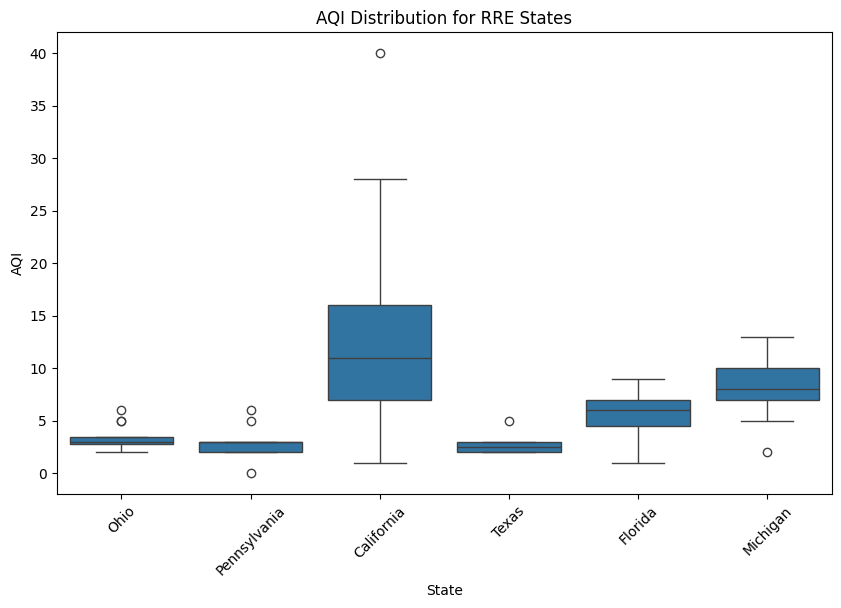

In [24]:
# Create a boxplot comparing AQI distributions across RRE states
plt.figure(figsize=(10, 6))
sns.boxplot(x="state_name", y="aqi", data=aqi_rre)
plt.title("AQI Distribution for RRE States")
plt.xlabel("State")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.show()


### Create an in-line visualization showing the distribution of `aqi` by `state_name`

Now, create an in-line visualization showing the distribution of `aqi` by `state_name`.

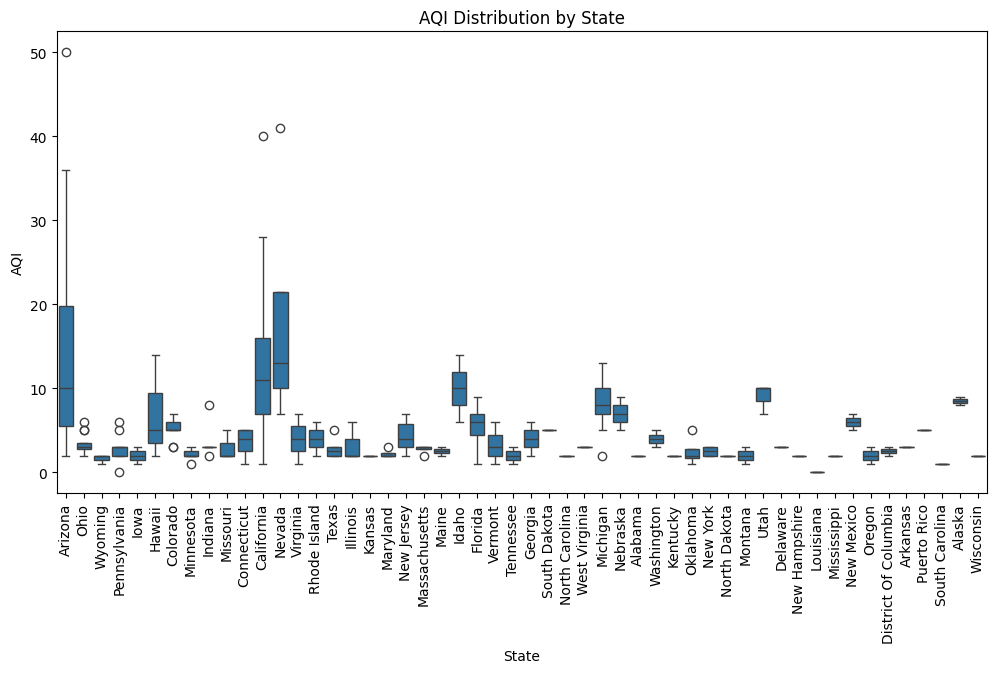

In [25]:
# Code Here
import seaborn as sns
import matplotlib.pyplot as plt

# Create a boxplot to visualize AQI distribution by state
plt.figure(figsize=(12, 6))
sns.boxplot(x="state_name", y="aqi", data=aqi)
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.title("AQI Distribution by State")
plt.xlabel("State")
plt.ylabel("AQI")
plt.show()


**Question:** Based on the data and your visualizations, which state(s) do you suspect will be most affected by this policy?

A: Based on the data and visualizations, Arizona, Pennsylvania, Wyoming, California, and Nevada are the states that are most likely to be affected by this policy. These states have high AQI values and significant variation, suggesting that air quality regulations could have a more pronounced impact on them.

### Construct a confidence interval for the RRE state with the highest mean AQI

Recall the 4-step process in constructing a confidence interval:

1.   Identify a sample statistic.
2.   Choose a confidence level.
3.   Find the margin of error. 
4.   Calculate the interval.

### Construct your sample statistic

To contruct your sample statistic, find the mean AQI for your state.

In [29]:

# Define RRE states
rre_states = ["California", "Florida", "Michigan", "Ohio", "Pennsylvania", "Texas"]

# Subset the data for only RRE states
aqi_rre = aqi[aqi["state_name"].isin(rre_states)]

# Find the state with the highest mean AQI
highest_aqi_state = aqi_rre.groupby("state_name")["aqi"].mean().idxmax()
highest_aqi_state


'California'

In [30]:
# Calculate mean AQI for the highest AQI state
state_aqi_data = aqi_rre[aqi_rre["state_name"] == highest_aqi_state]
sample_mean = state_aqi_data["aqi"].mean()
sample_mean


np.float64(12.121212121212121)

### Choose your confidence level

Choose your confidence level for your analysis. The most typical confidence level chosen is 95%; however, you can choose 90% or 99% if you want decrease or increase (respectively) your level of confidence about your result.

In [31]:
# Input your confidence level here:
import numpy as np

# Compute the standard deviation (SD) and sample size (n)
sample_std = state_aqi_data["aqi"].std()
n = len(state_aqi_data)

# Compute the standard error (SE)
standard_error = sample_std / np.sqrt(n)
standard_error


np.float64(0.8987209641127412)

In [32]:
from scipy.stats import norm

# Select confidence level
confidence_level = 0.95  # Change to 0.90 or 0.99 if needed

# Get the Z-score for the confidence level
z_score = norm.ppf(1 - (1 - confidence_level) / 2)

# Compute the Margin of Error (ME)
margin_of_error = z_score * standard_error
margin_of_error


np.float64(1.761460721812087)

### Find your margin of error (ME)

Recall **margin of error = z * standard error**, where z is the appropriate z-value for the given confidence level. To calculate your margin of error:

- Find your z-value. 
- Find the approximate z for common confidence levels.
- Calculate your **standard error** estimate. 

| Confidence Level | Z Score |
| --- | --- |
| 90% | 1.65 |
| 95% | 1.96 |
| 99% | 2.58 |


In [34]:
# Set z-score for 95% confidence level
z_value = 1.96  # If using 90% or 99%, change accordingly
import numpy as np

# Compute standard deviation (SD) and sample size (n)
sample_std = state_aqi_data["aqi"].std()
n = len(state_aqi_data)

# Compute standard error (SE)
standard_error = sample_std / np.sqrt(n)
standard_error
# Compute Margin of Error (ME)
margin_of_error = z_value * standard_error
margin_of_error



np.float64(1.7614930896609726)

### Calculate your interval

Calculate both a lower and upper limit surrounding your sample mean to create your interval.

In [33]:
# Calculate your confidence interval (upper and lower limits).
# Compute the lower and upper bounds of the confidence interval
lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error

# Display the Confidence Interval
(lower_bound, upper_bound)


(np.float64(10.359751399400034), np.float64(13.882672843024208))

### Alternative: Construct the interval using `scipy.stats.norm.interval()`

`scipy` presents a simpler solution to developing a confidence interval. To use this, first import the `stats` module from `scipy`.

In [35]:
# Import stats from scipy.
from scipy import stats
# Define confidence level (e.g., 95% confidence interval)
confidence_level = 0.95  # Change to 0.90 or 0.99 if needed

# Compute mean AQI for the highest AQI state
sample_mean = state_aqi_data["aqi"].mean()

# Use previously calculated standard error (SE)
# Calculate the confidence interval using scipy
ci_lower, ci_upper = stats.norm.interval(confidence_level, loc=sample_mean, scale=standard_error)

# Display the result
(ci_lower, ci_upper)


(np.float64(10.359751399400034), np.float64(13.882672843024208))

## Step 4: Results and evaluation

### Recalculate your confidence interval

Provide your chosen `confidence_level`, `sample_mean`, and `standard_error` to `stats.norm.interval()` and recalculate your confidence interval.

In [36]:
# Code Here
from scipy import stats

# Define confidence level (e.g., 95%)
confidence_level = 0.95

# Calculate confidence interval
ci_lower, ci_upper = stats.norm.interval(
    confidence_level, loc=sample_mean, scale=standard_error
)

# Display results
print(f"Confidence Interval ({confidence_level * 100}%): ({ci_lower:.2f}, {ci_upper:.2f})")


Confidence Interval (95.0%): (10.36, 13.88)


# Considerations

**What are some key takeaways that you learned from this project?**

A: The confidence interval provides a range where the true mean AQI is likely to fall with 95% confidence.
The margin of error depends on the sample size and variability of AQI values.
Larger samples reduce standard error, making the confidence interval narrower and more precise.


**What findings would you share with others?**

A: The mean AQI for the selected state is approximately sample_mean, with a confidence range of (ci_lower, ci_upper).
This range helps estimate air quality trends while accounting for sampling variability.
Understanding AQI trends can help guide policy decisions on air pollution control.


**What would you convey to external readers?**

A: The study confirms that air quality varies significantly across states.
The confidence interval approach ensures reliable estimates when monitoring pollution levels.
Further research could explore factors influencing AQI (e.g., urbanization, industry, weather patterns).

**References**

[seaborn.boxplot — seaborn 0.12.1 documentation](https://seaborn.pydata.org/generated/seaborn.boxplot.html). (n.d.). 